# **Step3. 속성 기반 감정 분류**

**미션 : 리뷰 안에 담긴 11가지 속성 감성 분석하기(Aspect-Based Sentiment Analysis)**
1) 목표 : 속성 기반 감성 분석을 통해, 리뷰 내용을 속성에 따라 긍, 부정
으로 분류하는 모델 생성
2) 절차① : “[ASPECT] 속성 [SEP] 문장”
    * 데이터 전처리 : 데이터셋 구성, 토크나이즈
    * 스페셜 토큰 추가 + 모델의 임베딩 층 resizing
    * 파인튜닝 및 모델 평가
3) 절차② : “Aspect : 문장”
    * 데이터 전처리 : 데이터셋 구성, 토크나이즈
    * 파인튜닝 및 모델 평가
4) 성능 비교 : “Aspect : 문장”
    * 모델 별 : klue/bert-base, klue/RoBERTa-base
    * 전처리 별 : Case①, Case②
    * Macro Recall, Macro Precision, Macro F1-Score 비교

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [ ]:
# 한글폰트 설치
import matplotlib as mpl
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'
!apt -qq -y install fonts-nanum

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import torch

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

### (2) 데이터 로딩
* data.csv 파일 로딩

In [ ]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
data = pd.read_csv('data.csv')
data.head()

,text,aspect,label
0,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,포장,1
1,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,품질,1
2,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,보습,1
3,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,포장,0
4,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,기타,1


* 전제 데이터 중 10,000건만 샘플링
    * 학습 속도 고려

In [ ]:
# sampling
data1 = data.sample(10000, random_state = 100)
data1.reset_index(drop=True, inplace=True)

### (3) GPU 설정
* GPU 사용을 위한 설정

In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.방식① : [ASPECT] 속성 [SEP] 문장

* 두가지 모델에 대해서 튜닝을 시도해봅시다.
    * model_name1 = "klue/bert-base"
    * model_name2 = "klue/roberta-base"

### (1) 데이터 준비
* 데이터셋 분할 및 텐서 데이터셋 변환
* 토크나이징 함수 안에서,
    * "[ASPECT] 속성 [SEP] 문장" 형태로 수정
    * 토크나이징

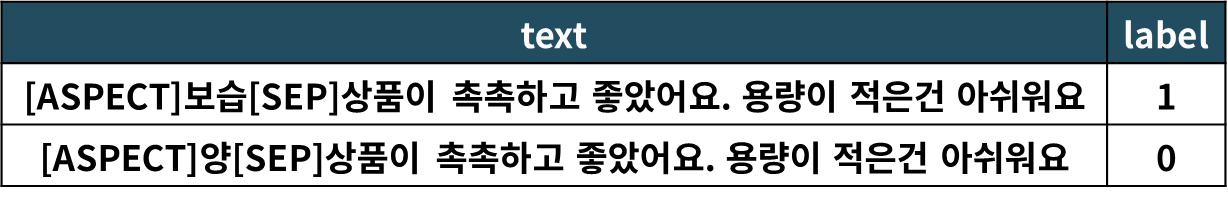

#### 1) 데이터셋 분할 및 텐서 데이터셋 변환

In [ ]:
aspects = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

In [ ]:
# train, val 데이터 분할
train, val = train_test_split(data1, test_size=0.3, random_state=100)

In [ ]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

In [ ]:
train_ts[:3]

{'text': ['여드름 진정시키려고 구매해봤습니다. 여드름은 그대로네요. 티트리 성분이 저한테는 효과가 없나봐요.',
  'OO에서 할인하길래 구매했습니다. 크림 뭐 살지 몰라서 제일 랭킹 높은 거 중에서 할인 많아 저렴한 걸로 구매했는데 랭킹 높은 이유를 알겠네요. 저는 우선 향이 너무 좋았어요. 향이 호불호가 갈리지 않은 은은향이고 되게 상쾌해서 바르면 제 기분까지 상쾌해집니다. 그리고 저는 아침저녁으로 발라주는데 너무 수분감 폭탄이지도 않고 끈적거림도 없어서 잘 바르고 있습니다. 적당한 유수분이 함유되어있어서 크림 보다는 약간 로션에 더 가까운 거 같아요. 바르면 번들거리지 않고 촉촉해서 너무 좋네요. 추천드려요~',
  '지속성 오래가고 피부가 산뜻함이 더해 여름에 지친 피부를 잘 매치 해주는거 같아요~!'],
 'aspect': ['품질', '향', '기타'],
 'label': [0, 1, 1],
 '__index_level_0__': [1191, 4458, 1131]}

#### 2) 토크나이징
* "[ASPECT] 속성 [SEP] 문장" 형태로 수정
* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

* 토크나이저 준비 : 두 모델에 대한 토크나이저 로딩

In [ ]:
model_name1 = "klue/bert-base"
tokenizer1 = AutoTokenizer.from_pretrained(model_name1)

model_name2 = "klue/roberta-base"
tokenizer2 = AutoTokenizer.from_pretrained(model_name2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

* 사용자 정의 스페셜 토큰 등록하기

In [ ]:
# 사용자 정의 스페셜 토큰 목록
special_tokens_dict = {"additional_special_tokens": ["[ASPECT]"]}

# 토크나이저에 추가
tokenizer1.add_special_tokens(special_tokens_dict)
tokenizer2.add_special_tokens(special_tokens_dict)

1

* 토크나이징을 포함한 함수 생성 및 적용

In [ ]:
# 모델1 전처리 함수
def preprocess_function1(data):
    combined = f"[ASPECT] {data['aspect']} [SEP] {data['text']}"
    tokenized = tokenizer1(combined, padding="max_length", truncation=True, max_length=128)
    tokenized["label"] = int(data["label"])
    return tokenized

# 모델1 전처리 적용
train_ts1 = train_ts.map(preprocess_function1, batched=False)
val_ts1 = val_ts.map(preprocess_function1, batched=False)

# 모델2 전처리 함수
def preprocess_function2(data):
    combined = f"[ASPECT] {data['aspect']} [SEP] {data['text']}"
    tokenized = tokenizer2(combined, padding="max_length", truncation=True, max_length=128)
    tokenized["label"] = int(data["label"])
    return tokenized

# 모델2 전처리 적용
train_ts2 = train_ts.map(preprocess_function2, batched=False)
val_ts2 = val_ts.map(preprocess_function2, batched=False)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

### (2) Fine-Tuning

#### 1) 사전학습 모델 준비
* 모델 로드한 후
* 반드시 `모델.resize_token_embeddings(len(tokenizer))`

In [ ]:
# 모델1
model1 = AutoModelForSequenceClassification.from_pretrained(model_name1, num_labels=2).to(device)     # class 0=부정, 1=긍정
model1.resize_token_embeddings(len(tokenizer1))

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(32001, 768, padding_idx=0)

In [ ]:
# 모델2
model2 = AutoModelForSequenceClassification.from_pretrained(model_name2, num_labels=2).to(device)     # class 0=부정, 1=긍정
model2.resize_token_embeddings(len(tokenizer2))

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding(32001, 768, padding_idx=1)

#### 2) 학습 설정

* TrainingArguments 설정
    * 두 모델에 공통으로 하나만 설정해도 됨

In [ ]:
# TrainingArguments 설정
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-6,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.03,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요. 가장 성능이 좋았던 에포크의 모델 선정
    logging_dir ='./logs',
    logging_steps = 10,
    report_to="tensorboard"
)

* Trainer 설정
    * 두 모델 각각 설정

In [ ]:
# Trainer1 설정
trainer1 = Trainer(
    model=model1,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts1,
    eval_dataset = val_ts1,
    tokenizer = tokenizer1,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

# Trainer2 설정
trainer2 = Trainer(
    model=model2,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts2,
    eval_dataset = val_ts2,
    tokenizer = tokenizer2,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

/tmp/ipython-input-1345654501.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer1 = Trainer(
/tmp/ipython-input-1345654501.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer2 = Trainer(


#### 3) 학습

In [ ]:
# 모델 학습
trainer1.train()

Epoch,Training Loss,Validation Loss
1,0.310500,0.312860
2,0.343600,0.290390
3,0.229300,0.278535
4,0.276300,0.270974
5,0.239800,0.266540


TrainOutput(global_step=1095, training_loss=0.30801161445983466, metrics={'train_runtime': 874.0671, 'train_samples_per_second': 40.043, 'train_steps_per_second': 1.253, 'total_flos': 2302221734400000.0, 'train_loss': 0.30801161445983466, 'epoch': 5.0})

In [ ]:
trainer2.train()

Epoch,Training Loss,Validation Loss
1,0.317900,0.316053
2,0.352000,0.272544
3,0.231000,0.266026
4,0.252400,0.256619
5,0.209300,0.256090


TrainOutput(global_step=1095, training_loss=0.31357190619864966, metrics={'train_runtime': 876.0697, 'train_samples_per_second': 39.951, 'train_steps_per_second': 1.25, 'total_flos': 2302221734400000.0, 'train_loss': 0.31357190619864966, 'epoch': 5.0})

#### 4) 모델 검증평가

* 예측

In [ ]:
val_ts1[:3]

{'text': ['친구들이 아이라이너로 이 제품을 추천해줘서 사용했어요!! 일단 저는 화장이 처음이라 고민했는데 제형 심이 얇아서 그런지 초보자가 사용해도 바르기 좋았습니다. 발림성도 부드럽게 그려져서 눈에 자극이 가지는 않았어요. 지속력도 좋아서 아침에 그리고 나가면 저녁까지는 살아있습니다. 컬러도 다양하고 실제로 발색도 나름 괜찮네요. 생각보다 용량도 많아서 오래 사용할 수 있을 것 같아요~~ 리무버로 제거해도 쉽게 지워지니 걱정은 노노~~ 초보자분들은 아이라이너는 OO~ 어떠세요?><',
  '뿌리염색 하려고 사용했는데 부드럽게 잘 안 발라지고 두피에 자극적인지 불편했어요. 염색 지속력도 짧게 느껴지네요.',
  '찬바람에 입술이 트고 각질이 생겨서 발라봤어요. 체리향이 기분까지 좋아지게 만드네요. 색은 거의 나지 않아서 좋고 학생들도 바르기 좋을 거 같아요. 비비 바르고 입술에 이거 바르면 얼굴이 생기 있어 보입니다.'],
 'aspect': ['편의성', '밀착', '향'],
 'label': [1, 0, 1],
 '__index_level_0__': [8018, 9225, 3854],
 'input_ids': [[2,
   32000,
   5347,
   2047,
   3,
   3949,
   7285,
   3651,
   4893,
   2445,
   2200,
   1504,
   3808,
   2069,
   4635,
   2097,
   2810,
   2112,
   3704,
   2371,
   10283,
   5,
   5,
   4458,
   1535,
   2259,
   4669,
   2052,
   3790,
   2052,
   2181,
   4445,
   2371,
   13964,
   22170,
   29052,
   1400,
   2227,
   2112,
   9408,
   10703,
   2155,
   2116,
   3704,
   2097,
   2119,
   5957,
   2

In [ ]:
# 검증 데이터셋으로 예측
raw_pred1 = trainer1.predict(val_ts1)

# 예측 결과
preds1 = raw_pred1.predictions.argmax(axis=1)  # 확률 -> 클래스
labels1 = raw_pred1.label_ids

In [ ]:
# 검증 데이터셋으로 예측
raw_pred2 = trainer2.predict(val_ts2)

# 예측 결과
preds2 = raw_pred2.predictions.argmax(axis=1)  # 확률 -> 클래스
labels2 = raw_pred2.label_ids

* 평가 : model1

In [ ]:
# 전체 정확도
print("Accuracy:", accuracy_score(labels1, preds1))

# 정밀도/재현율/F1 등 상세 리포트
print(classification_report(labels1, preds1, target_names=["Negative", "Positive"]))

Accuracy: 0.88
              precision    recall  f1-score   support

    Negative       0.80      0.75      0.78       835
    Positive       0.91      0.93      0.92      2165

    accuracy                           0.88      3000
   macro avg       0.85      0.84      0.85      3000
weighted avg       0.88      0.88      0.88      3000



In [ ]:
# pandas로 변환 (val_ts → 원래의 데이터셋 형태 필요)
val1 = val_ts1.to_pandas()
val1['pred'] = preds1

# 일부 결과 확인
val1[['text', 'aspect', 'label', 'pred']].head()

,text,aspect,label,pred
0,친구들이 아이라이너로 이 제품을 추천해줘서 사용했어요!! 일단 저는 화장이 처음이라...,편의성,1,1
1,뿌리염색 하려고 사용했는데 부드럽게 잘 안 발라지고 두피에 자극적인지 불편했어요. ...,밀착,0,0
2,찬바람에 입술이 트고 각질이 생겨서 발라봤어요. 체리향이 기분까지 좋아지게 만드네요...,향,1,1
3,이 제품 처음 나왔을 때부터 우와~ 감탄하며 사용했던 기억이 있네요. 지금까지 긴 ...,피부,1,1
4,자주 이용하는 제품인데요. 바를때도 잘발려지고 향도 좋습니다. 아들하고 하나씩 나눠...,밀착,1,1


In [ ]:
aspects

['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

In [ ]:
results = []

for aspect in aspects:
    sub = val1[val1['aspect'] == aspect]
    precision = precision_score(sub['label'], sub['pred'], zero_division=0)
    recall = recall_score(sub['label'], sub['pred'], zero_division=0)
    f1 = f1_score(sub['label'], sub['pred'], zero_division=0)
    results.append({'aspect': aspect, 'precision': precision, 'recall': recall, 'f1': f1})
df_scores = pd.DataFrame(results).sort_values('aspect')
df_melted = df_scores.melt(id_vars='aspect', var_name='metric', value_name='score')

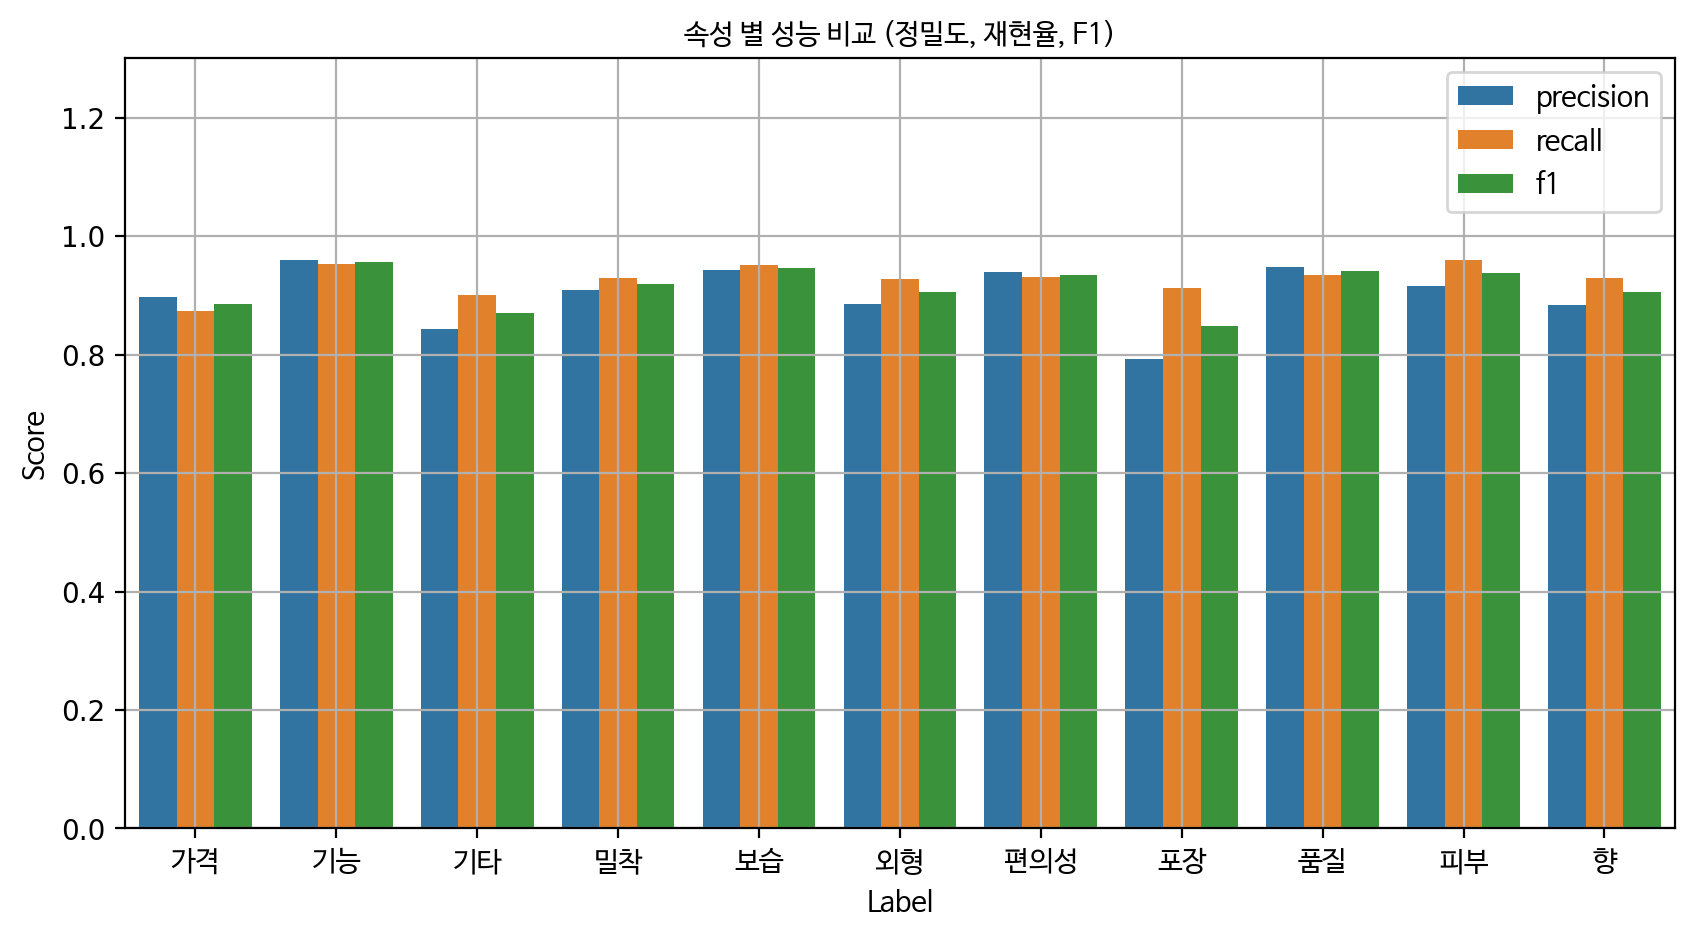

In [ ]:
# barplot 그리기
plt.figure(figsize=(10, 5))
sns.barplot(data=df_melted, x='aspect', y='score', hue='metric')

# 3. 한글 폰트 설정 (필요 시)
plt.xticks(fontproperties=fontprop)
plt.title("속성 별 성능 비교 (정밀도, 재현율, F1)", fontproperties=fontprop)
plt.ylabel("Score", fontproperties=fontprop)
plt.xlabel("Label", fontproperties=fontprop)
plt.ylim(0, 1.3)
plt.legend(prop=fontprop)
plt.grid()
plt.show()

* 평가 : model2

In [ ]:
# 전체 정확도
print("Accuracy:", accuracy_score(labels2, preds2))

# 정밀도/재현율/F1 등 상세 리포트
print(classification_report(labels2, preds2, target_names=["Negative", "Positive"]))

Accuracy: 0.8843333333333333
              precision    recall  f1-score   support

    Negative       0.82      0.74      0.78       835
    Positive       0.91      0.94      0.92      2165

    accuracy                           0.88      3000
   macro avg       0.86      0.84      0.85      3000
weighted avg       0.88      0.88      0.88      3000



In [ ]:
# pandas로 변환 (val_ts → 원래의 데이터셋 형태 필요)
val2 = val_ts2.to_pandas()
val2['pred'] = preds2

# 일부 결과 확인
val2[['text', 'aspect', 'label', 'pred']].head()

,text,aspect,label,pred
0,친구들이 아이라이너로 이 제품을 추천해줘서 사용했어요!! 일단 저는 화장이 처음이라...,편의성,1,1
1,뿌리염색 하려고 사용했는데 부드럽게 잘 안 발라지고 두피에 자극적인지 불편했어요. ...,밀착,0,0
2,찬바람에 입술이 트고 각질이 생겨서 발라봤어요. 체리향이 기분까지 좋아지게 만드네요...,향,1,1
3,이 제품 처음 나왔을 때부터 우와~ 감탄하며 사용했던 기억이 있네요. 지금까지 긴 ...,피부,1,1
4,자주 이용하는 제품인데요. 바를때도 잘발려지고 향도 좋습니다. 아들하고 하나씩 나눠...,밀착,1,1


In [ ]:
results = []

for aspect in aspects:
    sub = val2[val2['aspect'] == aspect]
    precision = precision_score(sub['label'], sub['pred'], zero_division=0)
    recall = recall_score(sub['label'], sub['pred'], zero_division=0)
    f1 = f1_score(sub['label'], sub['pred'], zero_division=0)
    results.append({'aspect': aspect, 'precision': precision, 'recall': recall, 'f1': f1})
df_scores2 = pd.DataFrame(results).sort_values('aspect')
df_melted2 = df_scores2.melt(id_vars='aspect', var_name='metric', value_name='score')

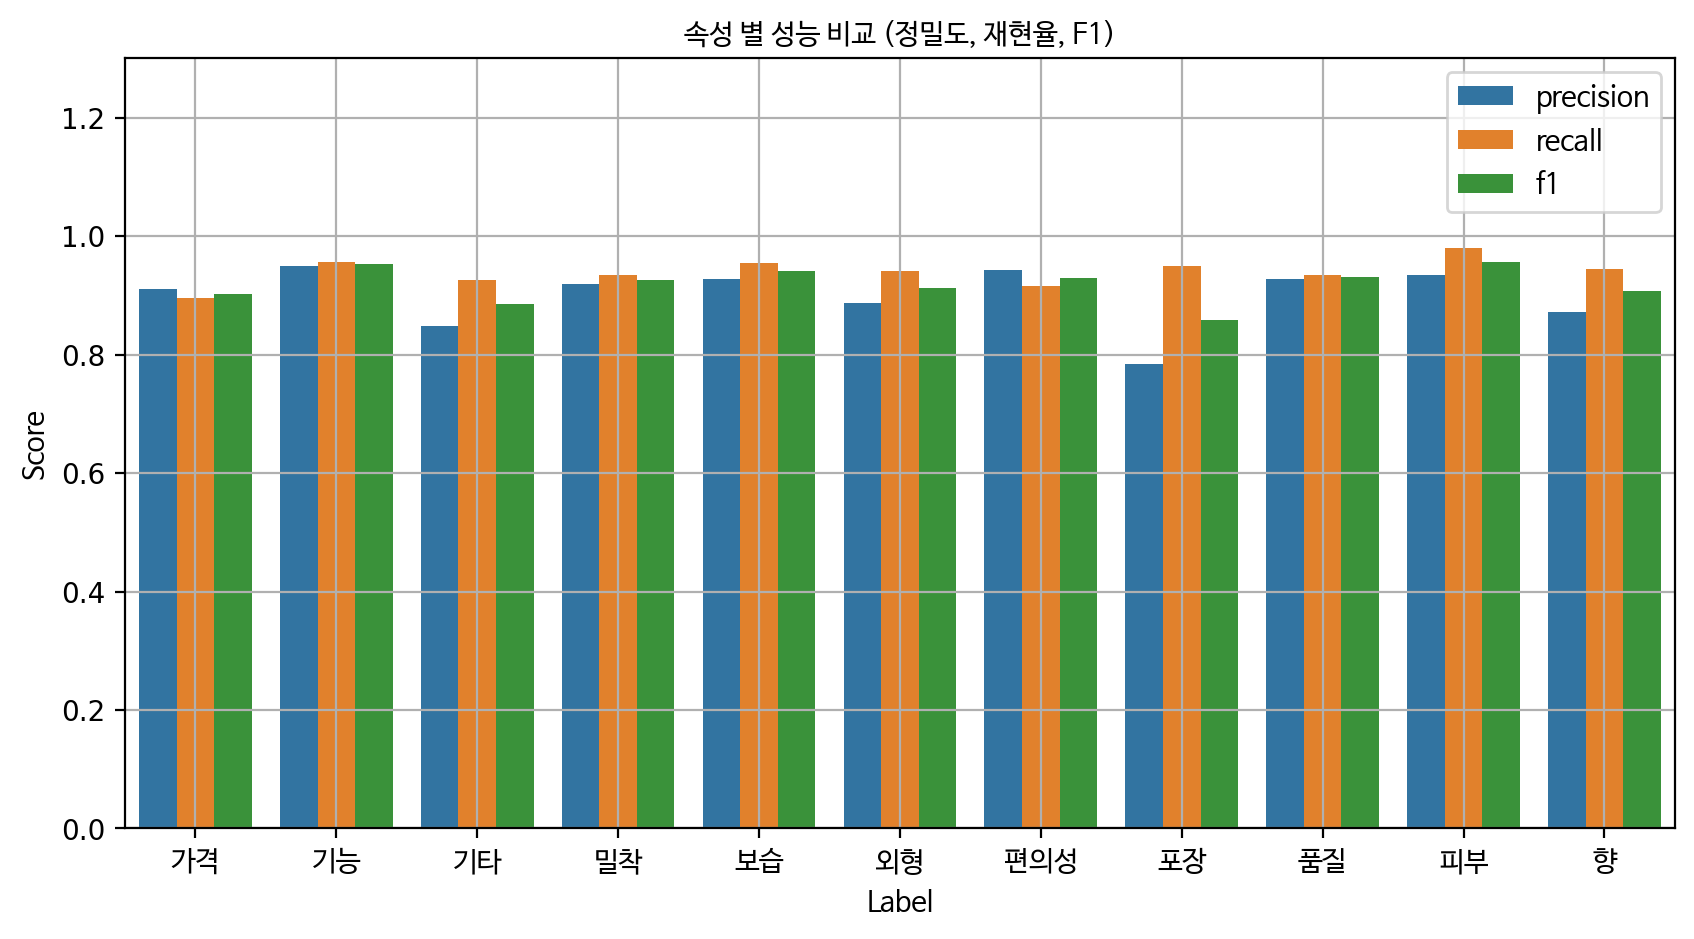

In [ ]:
# barplot 그리기
plt.figure(figsize=(10, 5))
sns.barplot(data=df_melted2, x='aspect', y='score', hue='metric')

# 3. 한글 폰트 설정 (필요 시)
plt.xticks(fontproperties=fontprop)
plt.title("속성 별 성능 비교 (정밀도, 재현율, F1)", fontproperties=fontprop)
plt.ylabel("Score", fontproperties=fontprop)
plt.xlabel("Label", fontproperties=fontprop)
plt.ylim(0, 1.3)
plt.legend(prop=fontprop)
plt.grid()
plt.show()

## 3.방식② : 속성 : 문장

* 두가지 모델에 대해서 튜닝을 시도해봅시다.
    * model_name1 = "klue/bert-base"
    * model_name2 = "klue/roberta-base"

### (1) 데이터 준비
* 데이터셋 분할 및 텐서 데이터셋 변환
* 토크나이징 함수 안에서,
    * "ASPECT : 문장" 형태로 수정
    * 토크나이징

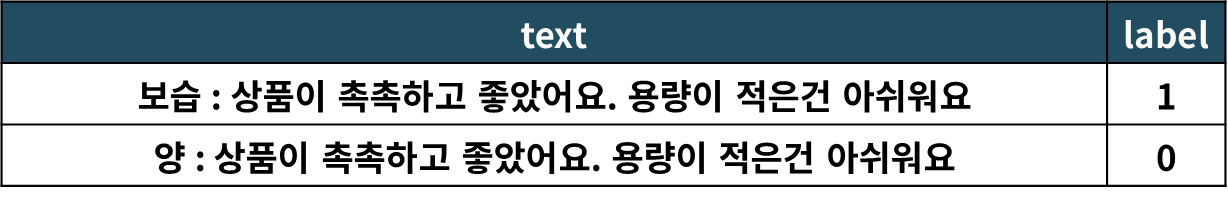

#### 1) 데이터셋 분할 및 텐서 데이터셋 변환

In [ ]:
aspects = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

In [ ]:
# train, val 데이터 분할
train, val = train_test_split(data1, test_size=0.3, random_state=100)

In [ ]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

In [ ]:
train_ts[:3]

{'text': ['여드름 진정시키려고 구매해봤습니다. 여드름은 그대로네요. 티트리 성분이 저한테는 효과가 없나봐요.',
  'OO에서 할인하길래 구매했습니다. 크림 뭐 살지 몰라서 제일 랭킹 높은 거 중에서 할인 많아 저렴한 걸로 구매했는데 랭킹 높은 이유를 알겠네요. 저는 우선 향이 너무 좋았어요. 향이 호불호가 갈리지 않은 은은향이고 되게 상쾌해서 바르면 제 기분까지 상쾌해집니다. 그리고 저는 아침저녁으로 발라주는데 너무 수분감 폭탄이지도 않고 끈적거림도 없어서 잘 바르고 있습니다. 적당한 유수분이 함유되어있어서 크림 보다는 약간 로션에 더 가까운 거 같아요. 바르면 번들거리지 않고 촉촉해서 너무 좋네요. 추천드려요~',
  '지속성 오래가고 피부가 산뜻함이 더해 여름에 지친 피부를 잘 매치 해주는거 같아요~!'],
 'aspect': ['품질', '향', '기타'],
 'label': [0, 1, 1],
 '__index_level_0__': [1191, 4458, 1131]}

#### 2) 토크나이징
* "ASPECT : 문장" 형태로 수정
* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

* 토크나이저 준비 : 두 모델에 대한 토크나이저 로딩

In [ ]:
model_name1 = "klue/bert-base"
tokenizer1 = AutoTokenizer.from_pretrained(model_name1)

model_name2 = "klue/roberta-base"
tokenizer2 = AutoTokenizer.from_pretrained(model_name2)

* 토크나이징을 포함한 함수 생성 및 적용

In [ ]:
# 모델1 전처리 함수
def preprocess_function1(data):
    combined = f"{data['aspect']} : {data['text']}"
    tokenized = tokenizer1(combined, padding="max_length", truncation=True, max_length=128)
    tokenized["label"] = int(data["label"])  # 확실히 1차원 int로 넣기
    return tokenized

# 모델1 전처리 적용
train_ts1 = train_ts.map(preprocess_function1, batched=False)
val_ts1 = val_ts.map(preprocess_function1, batched=False)

# 모델2 전처리 함수
def preprocess_function2(data):
    combined = f"{data['aspect']} : {data['text']}"
    tokenized = tokenizer2(combined, padding="max_length", truncation=True, max_length=128)
    tokenized["label"] = int(data["label"])  # 확실히 1차원 int로 넣기
    return tokenized

# 모델2 전처리 적용
train_ts2 = train_ts.map(preprocess_function2, batched=False)
val_ts2 = val_ts.map(preprocess_function2, batched=False)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

### (2) Fine-Tuning

#### 1) 사전학습 모델 준비

In [ ]:
model1 = AutoModelForSequenceClassification.from_pretrained(model_name1, num_labels=2).to(device)     # class 0=부정, 1=긍정

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model2 = AutoModelForSequenceClassification.from_pretrained(model_name2, num_labels=2).to(device)     # class 0=부정, 1=긍정

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### 2) 학습 설정

* TrainingArguments 설정
    * 두 모델에 공통으로 하나만 설정해도 됨

In [ ]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요. 가장 성능이 좋았던 에포크의 모델 선정
    logging_dir ='./logs',
    logging_steps = 10,
    report_to="tensorboard"
)

* Trainer 설정
    * 두 모델 각각 설정

In [ ]:
# Trainer 설정
trainer1 = Trainer(
    model=model1,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts1,
    eval_dataset = val_ts1,
    tokenizer = tokenizer1,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

# Trainer 설정
trainer2 = Trainer(
    model=model2,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts2,
    eval_dataset = val_ts2,
    tokenizer = tokenizer2,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

/tmp/ipython-input-2299865193.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer1 = Trainer(
/tmp/ipython-input-2299865193.py:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer2 = Trainer(


#### 3) 학습

In [ ]:
# 모델 학습
trainer1.train()

Epoch,Training Loss,Validation Loss
1,0.209600,0.247593


Epoch,Training Loss,Validation Loss
1,0.209600,0.247593


In [ ]:
trainer2.train()

#### 4) 모델 검증평가

* 예측

In [ ]:
# 검증 데이터셋으로 예측
pred_output1 = trainer1.predict(val_ts1)

# 예측 결과
preds1 = pred_output1.predictions.argmax(axis=1)  # 확률 -> 클래스
labels1 = pred_output1.label_ids

In [ ]:
# 검증 데이터셋으로 예측
pred_output2 = trainer2.predict(val_ts2)

# 예측 결과
preds2 = pred_output2.predictions.argmax(axis=1)  # 확률 -> 클래스
labels2 = pred_output2.label_ids

* 평가

In [ ]:
# 전체 정확도
print("Accuracy:", accuracy_score(labels1, preds1))

# 정밀도/재현율/F1 등 상세 리포트
print(classification_report(labels1, preds1, target_names=["Negative", "Positive"]))

In [ ]:
# 전체 정확도
print("Accuracy:", accuracy_score(labels2, preds2))

# 정밀도/재현율/F1 등 상세 리포트
print(classification_report(labels2, preds2, target_names=["Negative", "Positive"]))